# Visualising datasets

## 0.1. Imports and load data

In [38]:
import ase.io
from pathlib import Path
import numpy as np
import importlib
import torch
import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)


<module 'utils.training' from '/home/lim_yt/X-MACE-sampling/utils/training.py'>

In [3]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = 500  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = 500 # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))


base_atoms_list length: 500
transfer_atoms_list length: 500


## 0.2. Get descriptor matrix

In [59]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "energies", "encoded_energies", "soap", "acsf", "mbtr"]
DESCRIPTOR = DESCRIPTOR_TYPE[5]  # choose the descriptor type to use

# matrix of descriptors for each geometry
desc_matrix = []
for atom in transfer_atoms_list:
    desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom))
desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 270)
desc_matrix unique shape: (500, 270)
desc_matrix:
 [[3.98326130e+00 3.14880638e-01 1.82091503e+00 ... 4.06975659e-06
  1.62782168e-04 6.05321277e-08]
 [3.71187969e+00 2.91616152e-01 1.49726147e+00 ... 4.06857990e-06
  1.62587954e-04 6.05148582e-08]
 [3.74888106e+00 2.92799057e-01 1.52502472e+00 ... 4.06858562e-06
  1.62589408e-04 6.05149382e-08]
 ...
 [3.76360968e+00 2.93369795e-01 1.53729104e+00 ... 4.06858942e-06
  1.62590329e-04 6.05149921e-08]
 [3.85800072e+00 2.98920732e-01 1.63443190e+00 ... 4.06867407e-06
  1.62608134e-04 6.05162205e-08]
 [3.85083728e+00 2.98356364e-01 1.62584924e+00 ... 4.06866076e-06
  1.62605512e-04 6.05160259e-08]]


## 1. Pairwise distances

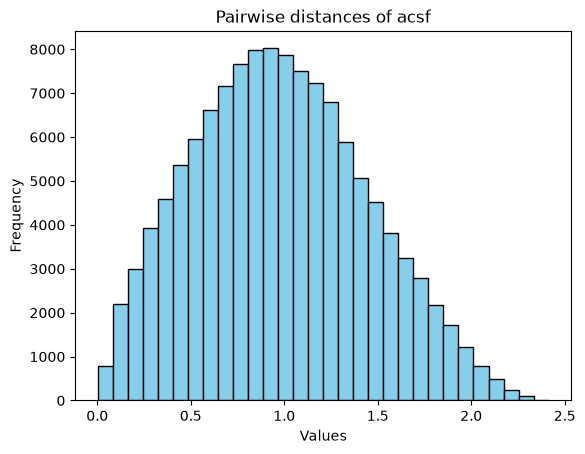

In [60]:
distances = pdist(desc_matrix)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Pairwise distances of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

## 2. PCA plot

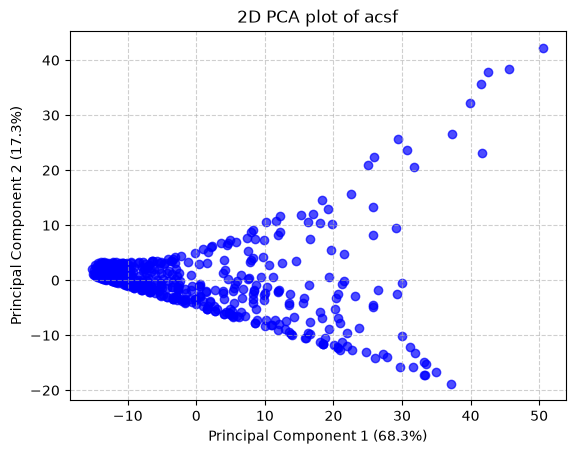

In [61]:
# 2D PCA

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=2)
desc_matrix_pca = pca.fit_transform(desc_matrix_scaled)

plt.scatter(desc_matrix_pca[:,0], desc_matrix_pca[:,1], color='blue', marker='o', alpha=0.7)
plt.title(f'2D PCA plot of {DESCRIPTOR}')
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


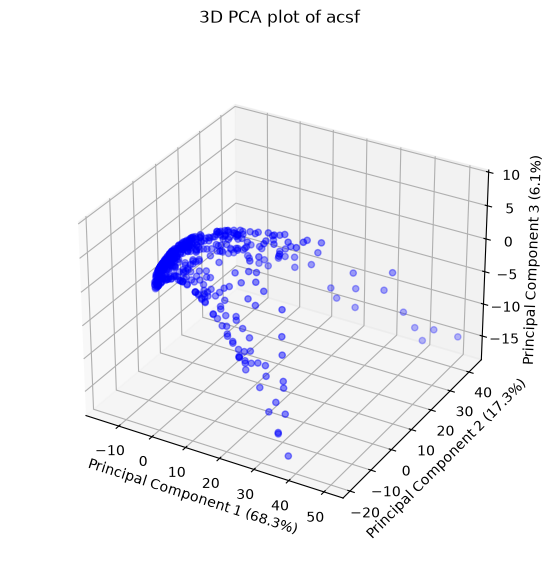

In [62]:
# 3D PCA

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=3)
desc_matrix_pca = pca.fit_transform(desc_matrix_scaled)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.85)
scatter = ax.scatter(desc_matrix_pca[:,0], desc_matrix_pca[:,1], desc_matrix_pca[:,2], color='blue', marker='o', alpha=0.7)
plt.title(f'3D PCA plot of {DESCRIPTOR}')
ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"Principal Component 3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()
